In [ ]:
import marimo as mo

# Function Calling

Gemini API の Function Calling 機能を使い、LLM がツールを呼び出す仕組みを体験する。
フレームワークを使わずに、while 文でツール呼び出しのループを自作する。

---

### このノートブックでやること

1. **Function Calling の基礎** — Python 関数をツールとして渡し、自動生成スキーマを確認する
2. **1往復の実行** — Function Call → ツール実行 → 結果返送 → 最終回答
3. **ループの実装** — while ループでツール呼び出しを繰り返す
4. **並列 Function Calling** — 複数ツールを1ターンで同時呼び出し

## Function Calling とは

LLM 単体では「現在の天気」「リアルタイムの情報」を知ることができません。
**Function Calling** は、LLM が「どのツールをどの引数で呼ぶべきか」を判断し、
その結果を受け取って最終回答を生成する仕組みです。

```
ユーザー: 「大阪の天気は？」
       ↓
LLM:  「get_weather("大阪") を呼んでください」  ← Function Call
       ↓
アプリ: get_weather("大阪") を実行 → {"weather": "曇り", ...}
       ↓
LLM:  「大阪は曇りで、気温22度です」            ← 最終回答
```

**重要**: LLM は実際にツールを実行しません。**どのツールを呼ぶかを指示するだけ**です。
実行はアプリケーション（今回はこのノートブック）が行います。

## ユースケース

Function Calling の用途は大きく2つに分けられます。

- **データ取得** — LLM が持てないリアルタイム情報を外部から取得する
  （例: 現在の天気、通貨換算、社内 DB の検索）
- **アクション実行** — 外部システムを操作する
  （例: フォーム送信、アプリ状態の更新、メール送信）

今回は **データ取得** のユースケースとして `get_current_location()` と `get_weather()` を実装します。

In [ ]:
from google import genai
from google.genai import types

client = genai.Client(
    vertexai=True,
    project="hr-mixi",
    location="global",
)
MODEL_NAME = "gemini-3-flash-preview"

## ツール関数の定義

今回は2つのモック関数を用意します。
実際のツールでは API やデータベースへのアクセスが入りますが、
ここではハードコードされた値を返します。

| 関数 | 引数 | 戻り値 | 役割 |
|------|------|--------|------|
| `get_current_location()` | なし | 現在地（都市名） | LLM が持てないリアルタイム情報の例 |
| `get_weather(location)` | 都市名 | 天気・気温・湿度 | 外部情報取得の例 |

In [ ]:
_WEATHER_DATA = {
    "東京": {"weather": "晴れ", "temperature_celsius": 25, "humidity_percent": 60},
    "大阪": {"weather": "曇り", "temperature_celsius": 22, "humidity_percent": 65},
    "札幌": {"weather": "雪", "temperature_celsius": -2, "humidity_percent": 80},
    "福岡": {"weather": "雨", "temperature_celsius": 18, "humidity_percent": 85},
    "名古屋": {"weather": "晴れ", "temperature_celsius": 23, "humidity_percent": 55},
}
_DEFAULT_WEATHER = {"weather": "晴れ", "temperature_celsius": 20, "humidity_percent": 60}

def get_current_location() -> dict:
    """ユーザーの現在地を取得する。

    Returns:
        現在地情報を含む辞書（city）
    """
    return {"city": "東京"}

def get_weather(location: str) -> dict:
    """指定された都市の現在の天気情報を取得する。

    Args:
        location: 都市名（例: 東京、大阪）

    Returns:
        天気情報を含む辞書（location, weather, temperature_celsius, humidity_percent）
    """
    data = _WEATHER_DATA.get(location, _DEFAULT_WEATHER)
    return {"location": location, **data}

mo.md(f"""
```python
get_current_location()
# → {get_current_location()}

get_weather("東京")
# → {get_weather("東京")}

get_weather("大阪")
# → {get_weather("大阪")}
```
""")

<span class="markdown prose dark:prose-invert contents"><div class="language-python codehilite"><pre><span></span><code><span class="n">get_current_location</span><span class="p">()</span>
<span class="c1"># → {&#39;city&#39;: &#39;東京&#39;}</span>

<span class="n">get_weather</span><span class="p">(</span><span class="s2">&quot;東京&quot;</span><span class="p">)</span>
<span class="c1"># → {&#39;location&#39;: &#39;東京&#39;, &#39;weather&#39;: &#39;晴れ&#39;, &#39;temperature_celsius&#39;: 25, &#39;humidity_percent&#39;: 60}</span>

<span class="n">get_weather</span><span class="p">(</span><span class="s2">&quot;大阪&quot;</span><span class="p">)</span>
<span class="c1"># → {&#39;location&#39;: &#39;大阪&#39;, &#39;weather&#39;: &#39;曇り&#39;, &#39;temperature_celsius&#39;: 22, &#39;humidity_percent&#39;: 65}</span>
</code></pre></div></span>

## ツールをモデルに渡す：Python 関数を直接渡す

`tools=[get_weather]` のように **Python 関数をそのまま渡す**と、
SDK が関数のシグネチャ・docstring・型アノテーションを解析して
**JSON Schema を自動生成**し、モデルに送信します。

SDK のデフォルトでは関数を自動実行するため、
レスポンスを手動で確認するために `automatic_function_calling` を無効にします。

```python
# 自動生成スキーマを確認する
decl = types.FunctionDeclaration.from_callable(callable=get_weather, client=client)
print(decl.parameters_json_schema)

# ツールを渡して generate_content を呼ぶ
response = client.models.generate_content(
    model=MODEL_NAME,
    contents="大阪の天気は？",
    config=types.GenerateContentConfig(
        tools=[get_weather],
        automatic_function_calling=types.AutomaticFunctionCallingConfig(disable=True),
    ),
)
```

In [ ]:
import json

# SDK が自動生成するスキーマを確認する
# from_callable() は parameters_json_schema ではなく parameters (Schema オブジェクト) を設定する
_decl = types.FunctionDeclaration.from_callable(callable=get_weather, client=client)
_schema_str = json.dumps(_decl.model_dump(exclude_none=True), ensure_ascii=False, indent=2)

# ① ユーザープロンプトを送信 → function_call が返る
_user_content = types.Content(
    role="user",
    parts=[types.Part.from_text(text="大阪の天気は？")],
)
_response1 = client.models.generate_content(
    model=MODEL_NAME,
    contents=[_user_content],
    config=types.GenerateContentConfig(
        tools=[get_weather],
        automatic_function_calling=types.AutomaticFunctionCallingConfig(disable=True),
    ),
)
_fc = _response1.function_calls[0]

# ② ツールを実行
_result = get_weather(**dict(_fc.args))

# ③ FunctionResponse を組み立てて返送 → 最終回答を取得
_fn_response_content = types.Content(
    role="tool",
    parts=[types.Part.from_function_response(name=_fc.name, response={"result": _result})],
)
_response2 = client.models.generate_content(
    model=MODEL_NAME,
    contents=[
        _user_content,
        _response1.candidates[0].content,  # モデルの function_call
        _fn_response_content,  # ツールの実行結果
    ],
    config=types.GenerateContentConfig(
        tools=[get_weather],
        automatic_function_calling=types.AutomaticFunctionCallingConfig(disable=True),
    ),
)

mo.md(f"""
**SDK が `get_weather` 関数から自動生成したツールスキーマ（全体）**:
```json
{_schema_str}
```

---

**① Function Call**（プロンプト: 「大阪の天気は？」）:
```
name : {_fc.name}
args : {dict(_fc.args)}
```

**② ツール実行**: `get_weather("大阪")` → `{_result}`

**③ 最終回答**:
> {_response2.text}
""")

<span class="markdown prose dark:prose-invert contents"><span class="paragraph"><strong>SDK が <code>get_weather</code> 関数から自動生成したツールスキーマ（全体）</strong>:
<div class="language-json codehilite"><pre><span></span><code><span class="p">{</span>
<span class="w">  </span><span class="nt">&quot;description&quot;</span><span class="p">:</span><span class="w"> </span><span class="s2">&quot;指定された都市の現在の天気情報を取得する。\n\nArgs:\n    location: 都市名（例: 東京、大阪）\n\nReturns:\n    天気情報を含む辞書（location, weather, temperature_celsius, humidity_percent）&quot;</span><span class="p">,</span>
<span class="w">  </span><span class="nt">&quot;name&quot;</span><span class="p">:</span><span class="w"> </span><span class="s2">&quot;get_weather&quot;</span><span class="p">,</span>
<span class="w">  </span><span class="nt">&quot;parameters&quot;</span><span class="p">:</span><span class="w"> </span><span class="p">{</span>
<span class="w">    </span><span class="nt">&quot;properties&quot;</span><span class="p">:</span><span class="w"> </span><span class="p">{</span>
<span class="w">      </span><span class="nt">&quot;location&quot;</span><span class="p">:</span><span class="w"> </span><span class="p">{</span>
<span class="w">        </span><span class="nt">&quot;type&quot;</span><span class="p">:</span><span class="w"> </span><span class="s2">&quot;STRING&quot;</span>
<span class="w">      </span><span class="p">}</span>
<span class="w">    </span><span class="p">},</span>
<span class="w">    </span><span class="nt">&quot;required&quot;</span><span class="p">:</span><span class="w"> </span><span class="p">[</span>
<span class="w">      </span><span class="s2">&quot;location&quot;</span>
<span class="w">    </span><span class="p">],</span>
<span class="w">    </span><span class="nt">&quot;type&quot;</span><span class="p">:</span><span class="w"> </span><span class="s2">&quot;OBJECT&quot;</span>
<span class="w">  </span><span class="p">},</span>
<span class="w">  </span><span class="nt">&quot;response&quot;</span><span class="p">:</span><span class="w"> </span><span class="p">{</span>
<span class="w">    </span><span class="nt">&quot;type&quot;</span><span class="p">:</span><span class="w"> </span><span class="s2">&quot;OBJECT&quot;</span>
<span class="w">  </span><span class="p">}</span>
<span class="p">}</span>
</code></pre></div></span>
<hr />
<span class="paragraph"><strong>① Function Call</strong>（プロンプト: 「大阪の天気は？」）:
<div class="language-scdoc codehilite"><pre><span></span><code>name : get_weather
args : {&#39;location&#39;: &#39;大阪&#39;}
</code></pre></div></span>
<span class="paragraph"><strong>② ツール実行</strong>: <code>get_weather("大阪")</code> → <code>{'location': '大阪', 'weather': '曇り', 'temperature_celsius': 22, 'humidity_percent': 65}</code></span>
<span class="paragraph"><strong>③ 最終回答</strong>:</span>
<blockquote>
<span class="paragraph">大阪の現在の天気は曇りで、気温は22度、湿度は65%です。</span>
</blockquote></span>

## ループの実装

手動1往復を **while ループ** に一般化します。
LLM が `function_calls` を返す限りループを続け、
テキスト回答が返った時点で終了します。

```python
while True:
    response = client.models.generate_content(model, contents, config)

    if not response.function_calls:
        break  # テキスト回答 → 終了

    for fc in response.function_calls:
        result = dispatch(fc.name, fc.args)  # ツール実行
        # FunctionResponse を contents に追加
```

今回のタスク「**現在地の天気を教えて**」では：

1. `get_current_location()` を呼んで現在地（東京）を取得
2. `get_weather("東京")` を呼んで天気を取得
3. 最終回答を生成

という **2ステップのループ** が発生します。

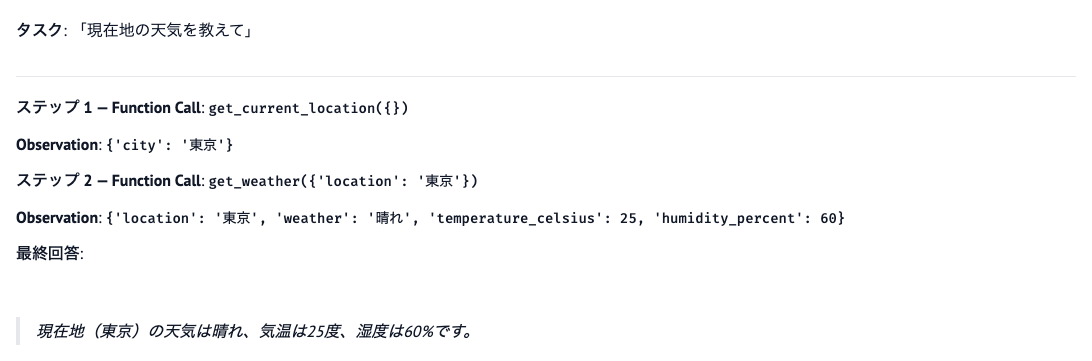

In [ ]:
_TOOL_MAP = {
    "get_current_location": get_current_location,
    "get_weather": get_weather,
}

_user_prompt = "現在地の天気を教えて"
_contents = [types.Content(role="user", parts=[types.Part.from_text(text=_user_prompt)])]
_config = types.GenerateContentConfig(
    tools=[get_current_location, get_weather],
    automatic_function_calling=types.AutomaticFunctionCallingConfig(disable=True),
)

mo.output.append(mo.md(f"**タスク**: 「{_user_prompt}」\n\n---"))

_step = 0
while True:
    _step += 1
    _response = client.models.generate_content(
        model=MODEL_NAME,
        contents=_contents,
        config=_config,
    )

    if not _response.function_calls:
        mo.output.append(mo.md(f"**最終回答**:\n> {_response.text}"))
        break

    _fn_parts = []
    for _fc in _response.function_calls:
        mo.output.append(mo.md(f"**ステップ {_step} — Function Call**: `{_fc.name}({dict(_fc.args)})`"))
        _fn = _TOOL_MAP[_fc.name]
        _result = _fn(**dict(_fc.args))
        mo.output.append(mo.md(f"**Observation**: `{_result}`"))
        _fn_parts.append(types.Part.from_function_response(name=_fc.name, response={"result": _result}))

    _contents.append(_response.candidates[0].content)
    _contents.append(types.Content(role="tool", parts=_fn_parts))

## 並列 Function Calling

Gemini 3 では、**1回のレスポンスで複数の Function Call を同時に返す**ことができます。
「東京と大阪の天気を同時に教えて」のように **独立した複数のツール呼び出し** が
必要な場合、逐次実行より効率的です。

```python
# モデルが1ターンで複数の function_calls を返す
response.function_calls
# → [FunctionCall(name="get_weather", args={"location": "東京"}),
#     FunctionCall(name="get_weather", args={"location": "大阪"})]
```

すべての結果を **1つの Content にまとめて** 返送します。

In [ ]:
_user_prompt = "東京と大阪の天気を同時に教えて"
_user_content = types.Content(role="user", parts=[types.Part.from_text(text=_user_prompt)])
_config = types.GenerateContentConfig(
    tools=[get_weather],
    automatic_function_calling=types.AutomaticFunctionCallingConfig(disable=True),
)

# 1回目: 並列 function_calls が返る
_response1 = client.models.generate_content(
    model=MODEL_NAME,
    contents=[_user_content],
    config=_config,
)

# 全 function_calls を実行し、まとめて返送
_fn_parts = []
_call_log = []
for _fc in _response1.function_calls:
    _result = get_weather(**dict(_fc.args))
    _call_log.append(f"`{_fc.name}({dict(_fc.args)})` → `{_result}`")
    _fn_parts.append(types.Part.from_function_response(name=_fc.name, response={"result": _result}))

# 2回目: 最終回答
_response2 = client.models.generate_content(
    model=MODEL_NAME,
    contents=[
        _user_content,
        _response1.candidates[0].content,
        types.Content(role="tool", parts=_fn_parts),
    ],
    config=_config,
)

_calls_md = "\n".join(f"- {log}" for log in _call_log)
mo.md(f"""
**プロンプト**: 「{_user_prompt}」

**並列 Function Calls**（1ターンで同時に返された）:

{_calls_md}

**最終回答**:
> {_response2.text}
""")

<span class="markdown prose dark:prose-invert contents"><span class="paragraph"><strong>プロンプト</strong>: 「東京と大阪の天気を同時に教えて」</span>
<span class="paragraph"><strong>並列 Function Calls</strong>（1ターンで同時に返された）:</span>
<ul>
<li><code>get_weather({'location': '東京'})</code> → <code>{'location': '東京', 'weather': '晴れ', 'temperature_celsius': 25, 'humidity_percent': 60}</code></li>
<li><code>get_weather({'location': '大阪'})</code> → <code>{'location': '大阪', 'weather': '曇り', 'temperature_celsius': 22, 'humidity_percent': 65}</code></li>
</ul>
<span class="paragraph"><strong>最終回答</strong>:</span>
<blockquote>
<span class="paragraph">東京は晴れで、気温は25度、湿度は60%です。
大阪は曇りで、気温は22度、湿度は65%です。</span>
</blockquote></span>

## まとめ

| 概念 | ポイント |
|------|----------|
| **Function Calling** | LLM はツールを「呼ぶよう指示」するだけ。実行はアプリ側 |
| **自動スキーマ生成** | Python 関数をそのまま渡すと SDK が JSON Schema に変換 |
| **手動実行** | `function_calls` → 実行 → `Part.from_function_response` → 返送 |
| **ループ実装** | `function_calls` がなくなるまで while ループで繰り返す |
| **並列 Function Calling** | 1ターンで複数の `function_calls` が返る場合は同時実行して一括返送 |

---

### ハンズオン課題

- 新しいツールを作って Function Calling を試してみよう